In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from load_meop import MEOP

fname = '../data/qc_profile_ds_2dbar.nc'

In [3]:
ds = xr.open_dataset(fname)

In [4]:
ds = ds.swap_dims({'n_prof':'time'})

In [6]:
extent = [138.5,143,-67,-65.6]
tstart = pd.Timestamp(2007,2,1)
tend = pd.Timestamp(2007,3,1)
ds_mertz = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
).sel(time=slice(tstart,tend))

In [7]:
meop = MEOP(extent)
meop.load_profiles()

100%|██████████| 81/81 [03:23<00:00,  2.52s/it]


,platform,latitude,longitude,filename,temperature,salinity,gph,nlevels
time,,,,,,,,
2007-02-20 15:19:59,wd3-CTD2-07,-66.6190,139.9200,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.149898,10
2007-02-20 23:29:59,wd3-CTD2-07,-66.5560,140.0420,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.161139,19
2007-02-21 04:40:00,wd3-CTD2-07,-66.5868,140.0270,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.129097,10
2007-02-21 08:39:58,wd3-CTD2-07,-66.5839,139.9780,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.171173,19
2007-02-21 17:29:59,wd3-CTD2-07,-66.6441,140.0330,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.154512,10
...,...,...,...,...,...,...,...,...
2019-06-08 07:49:59,wd11-768-18,-66.6608,141.3027,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.013696,36
2019-06-08 23:09:59,wd11-768-18,-66.6508,141.3139,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.027960,16
2019-06-09 15:50:00,wd11-768-18,-66.6525,141.3284,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.028732,16


In [8]:
ds_mertz_meop=ds_mertz.where(ds_mertz.dsource=='MEOP',drop=True)

In [10]:
df_mertz=meop.df[(meop.df.index > tstart) & (meop.df.index < tend)]

In [12]:
ds_mertz_meop

<xarray.Dataset> Size: 159kB
Dimensions:  (time: 11, pres: 501)
Coordinates:
    lon      (time) float64 88B 140.0 140.0 140.0 140.0 ... 140.0 140.0 140.0
    lat      (time) float64 88B -66.56 -66.58 -66.66 ... -66.57 -66.44 -66.5
  * time     (time) datetime64[ns] 88B 2007-02-20T23:29:59.000002 ... 2007-02...
    n_prof   (time) int64 88B 793190 793191 793247 ... 793196 793197 793198
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp     (time, pres) float64 44kB nan nan nan -1.339 ... nan nan nan nan
    psal     (time, pres) float64 44kB nan nan nan 33.86 ... nan nan nan nan
    dsource  (time) object 88B 'MEOP' 'MEOP' 'MEOP' ... 'MEOP' 'MEOP' 'MEOP'
    mld      (time) float64 88B 65.34 17.82 49.5 49.5 ... 49.5 19.8 74.24 49.5
    asal     (time, pres) float32 22kB nan nan nan 34.02 ... nan nan nan nan
    ctemp    (time, pres) float32 22kB nan nan nan -1.335 ... nan nan nan nan
    rho      (time, pres) float32 22kB nan nan nan 1.027e+03 ... nan nan nan nan
    mlp      (time) float64 88B 52.0 14.0 42.0 50.0 50.0 ... 44.0 20.0 72.0 46.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [13]:
#df_months = meop.df.index.to_period('M')
#ds_months = pd.PeriodIndex(ds_mertz_meop.time.values.astype('datetime64[M]'),freq='M')
df_mertz[df_mertz.index.isin(ds_mertz_meop.time)].dropna()

,platform,latitude,longitude,filename,temperature,salinity,gph,nlevels
time,,,,,,,,
2007-02-28 02:49:59,wd3-CTD2-07,-66.4359,139.966,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.168318,19


(0.0, 3.0)

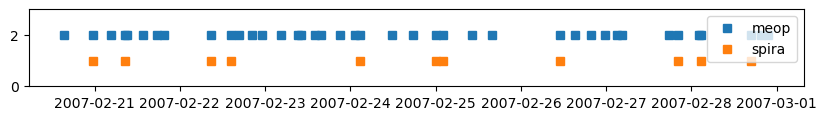

In [19]:
fig, ax = plt.subplots(figsize=(10,1))
ax.plot(df_mertz.index,[2 for t in df_mertz.index],marker='s',label='meop',linestyle='None')
ax.plot(ds_mertz_meop.time,[1 for t in ds_mertz_meop.time],marker='s',label='spira',linestyle='None')
ax.legend()
ax.set_ylim([0,3])


In [50]:
tprof=df_mertz.iloc[15]
tprof

platform                                             wd3-CTD2-07
latitude                                                -66.6523
longitude                                                139.937
filename       /nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...
temperature    [[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...
salinity       [[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...
gph                                                     0.142751
nlevels                                                       19
Name: 2007-02-25 15:49:58, dtype: object

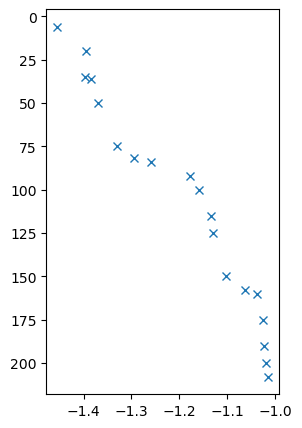

In [51]:
tprof=df_mertz.iloc[15].temperature[0]
fig,ax=plt.subplots(figsize=(3,5))
ax.plot(tprof,tprof.pressure,marker='x',linestyle='None')
ax.invert_yaxis()

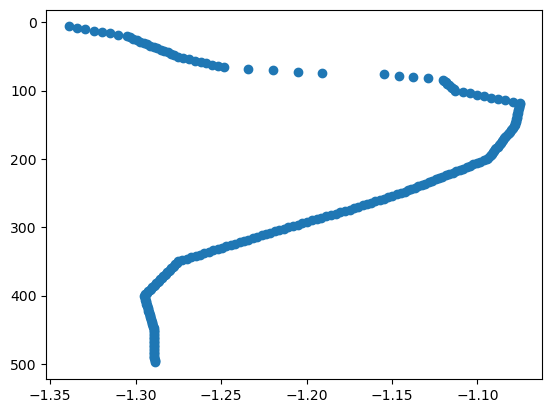

In [19]:
plt.scatter(x,y)
plt.gca().invert_yaxis()

In [1]:
extent = [145,160,-66,-68]
ds_cook = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

NameError: name 'ds' is not defined